In [20]:
# python 3.10.16
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
df = pd.read_csv("/Users/rorihoover/fixed_final_data.csv")

<positron-console-cell-57>:1: DtypeWarning: Columns (42,43,44,45,46,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.


In [58]:
columns_to_drop = ['Unnamed: 0.2', 'Unnamed: 0.1', 'first_photo.id', 'first_photo.sort_order', 'first_photo.user_id','first_photo.x_offset','first_photo.y_offset','first_photo.square_url','first_photo.medium_url','first_photo.thumbnail_url','first_photo.small_url','first_photo.medium2_url','first_photo.small2_url','first_photo.caption','first_photo.caption_html','first_photo.copyright_holder','first_photo.aspect_ratio','user.tiny_photo_url','user.small_photo_url','user.photo_url','Unnamed: 0','first_photo']
df = df.drop(columns=columns_to_drop)


In [59]:
columns_to_drop = ['ends_per_inch','picks_per_inch','links.self.href','personal_attributes']
df = df.drop(columns=columns_to_drop)

In [ ]:
# goal is for each variable (that the user does not have to record) to see what proportion of projects have a value. 
# do the varibles that people record change over time?

In [133]:
no_punc = df[~df['made_for'].str.contains(r'[^\w\s]', na=False)]
no_punc = (no_punc['made_for'].str.lower().str.strip())
no_punc.value_counts().head(20)

made_for
me             141830
myself          53606
mom             17844
charity         16589
self            15250
gift            11675
friend           7795
donation         7410
sale             6499
daughter         5254
fun              5120
my daughter      4460
a friend         4257
test             4253
etsy             3790
my mom           3465
moi              3367
dad              2960
sister           2830
my sister        2805
Name: count, dtype: int64

In [ ]:
#take out all the feilds with punctuation to process first and seperatly 
punc = df[df['made_for'].str.contains(r'[^\w\s]', na=False)]
punc = (punc['made_for'].str.lower().str.strip())
punc.value_counts().head(20)
# handle lone ! and ?
# co-worker -> coworker, mother-in-law ->mother in law, sister-in-law -> sister in law

# remove ! and ? from the end of expressions 


# reintegrate feilds 

#process altogether 
# all lowercase 
# remove "a " and "my " at the begining of entries 

made_for
me!                  21555
?                     4081
me :)                 1634
??                    1261
myself!               1231
me?                   1154
???                   1078
me!!                  1009
co-worker              970
gift/charity           963
wool-aid               815
fun!                   778
me!!!                  670
friend's baby          560
mother-in-law          554
sister-in-law          451
don't know yet         363
moi!                   341
friend's daughter      314
pbh-me                 311
Name: count, dtype: int64

In [94]:
clean = (
    df['made_for']
    .str.lower()
    .str.strip()
)

# now replace whole words only
clean = clean.replace(
    r'\b(me|myself|self|moi)\b[\s!?.:;)*]*',
    'self',
    regex=True
)
clean = clean.replace(r'\b(my mom|mother|my mother)\b', 'mom', regex=True)
clean = clean.replace(r'\bmy sister\b', 'sister', regex=True)
clean = clean.replace(r'\b(mil|mom-in-law|mom in law|mother in law)\b', 'mom', regex=True)
clean = clean.replace(r'\bmy niece\b', 'niece', regex=True)
clean = clean.replace(r'\bmy nephew\b', 'nephew', regex=True)
clean = clean.replace(r'\bmy family\b', 'family', regex=True)
clean = clean.replace(r'\bmy daughter\b', 'daughter', regex=True)
clean = clean.replace(r'\bmy son\b', 'son', regex=True)
clean = clean.replace(r'\bmy brother\b', 'brother', regex=True)
clean = clean.replace(r'\ba friend\b', 'friend', regex=True)
clean = clean.replace(r'\b(charity|project linus)\b', 'donation', regex=True)
clean = clean.replace(r'\b(a gift|gifts|gifting)\b', 'gift', regex=True)
clean = clean.replace(r'\b(hubby|my hubby|my husband)\b', 'husband', regex=True)
clean = clean.replace(
    r'\b((just\s+)?for fun|the fun of it|pleasure|fun)\b[\s!?.:;)*]*',
    'fun',
    regex=True
)
clean = clean.replace(r'^\?+$', 'unknown', regex=True)
clean = clean.replace(r'\b(pattern test|testing|pattern testing)\b', 'test', regex=True)
#replace co_worker with coworker
clean = clean.replace('co-worker', 'coworker')
clean = clean.replace(r'\b(customer|commission|sale|etsy shop|etsy|sale|my etsy shop|craft fair|sale|to sell|shop|bussiness sample|custom order|bussiness sample|sample|crochet doxology)\b', 'bussiness', regex=True)

clean.value_counts()


made_for
self                  243410
donation               26727
mom                    25672
bussiness              20520
gift                   15550
                       ...  
20 cheerleaders            1
germantown library         1
koa whale                  1
friend & kids              1
honeybee                   1
Name: count, Length: 224207, dtype: int64

In [93]:
counts = clean.value_counts().head(100)


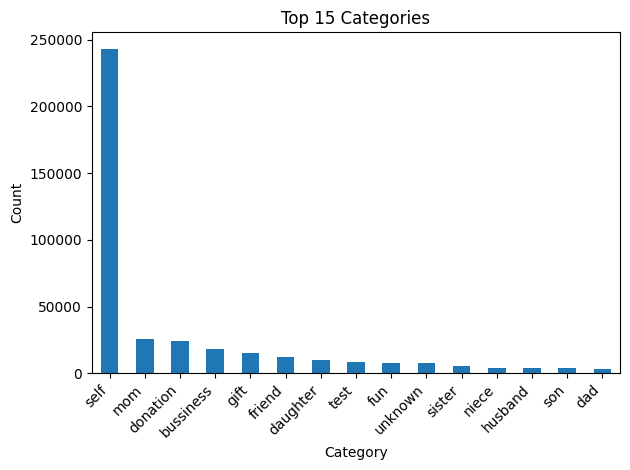

In [ ]:
#plot top 15
counts = clean.value_counts().head(15)

counts.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Top 15 Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#track top 10 tags over time using the year from df['created_at']

In [ ]:
#new column called lag that is the diff between df['created_at'] and df['started'] only for projects that df['started_day_set'] = True
print(df['created_at'].head())
print(df['started_day_set'].head())
print(df['started'].head())

0    2024/11/19 18:11:15 -0500
1    2018/07/13 15:37:08 -0400
2    2016/09/03 17:49:40 -0400
3    2020/08/30 15:43:09 -0400
4    2015/04/01 22:01:30 -0400
Name: created_at, dtype: object
0    False
1     True
2    False
3     True
4    False
Name: started_day_set, dtype: bool
0           NaN
1    2018/07/13
2           NaN
3    2020/08/26
4           NaN
Name: started, dtype: object


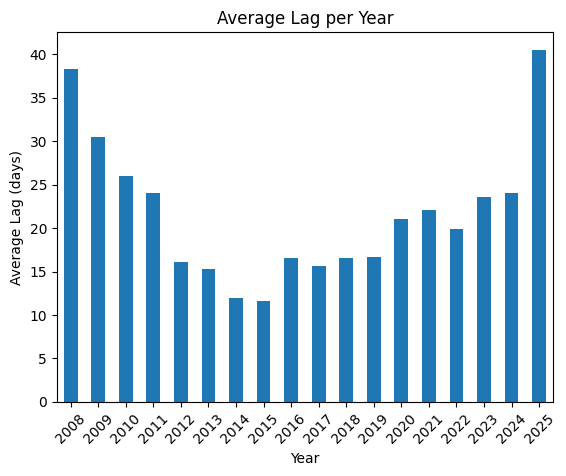

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag in days 
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract year
df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]
# Group and average
avg_lag_per_year = plot_df.groupby('year')['lag_days'].mean()

# Bar chart
plt.figure()
avg_lag_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Lag (days)")
plt.title("Average Lag per Year")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

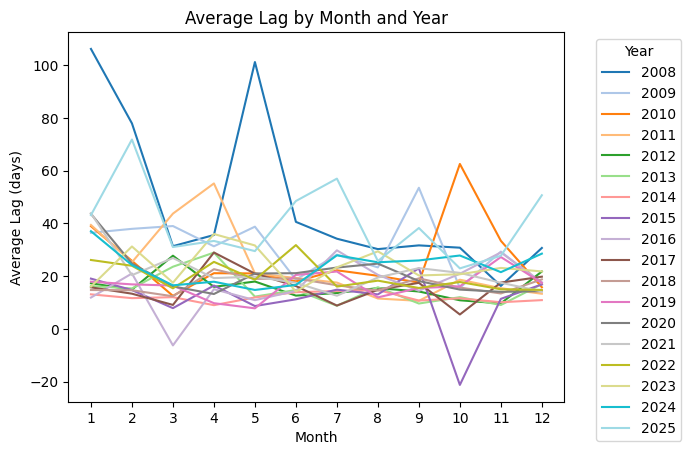

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract year + month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# Filter incomplete 
plot_df = df[~df['year'].isin([2007, 2026])]

# Group by year + month
grouped = plot_df.groupby(['year', 'month'])['lag_days'].mean().reset_index()

# Pivot → rows = month, columns = year (each line = a year)
pivot = grouped.pivot(index='month', columns='year', values='lag_days')

# Plot
plt.figure()
pivot.plot(kind='line', cmap='tab20')

plt.xlabel("Month")
plt.ylabel("Average Lag (days)")
plt.title("Average Lag by Month and Year")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<Figure size 640x480 with 0 Axes>

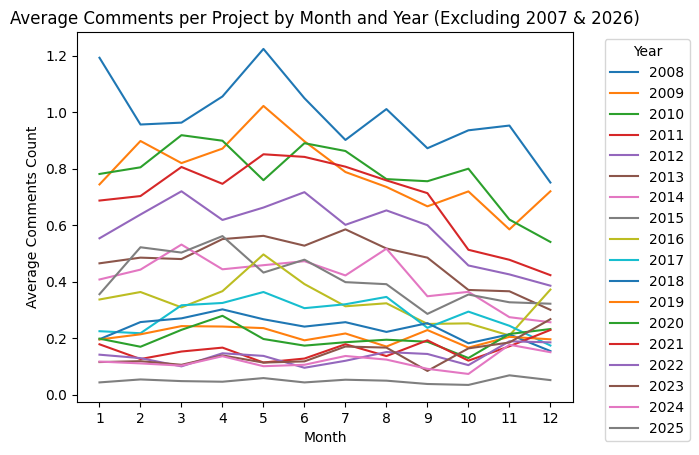

In [109]:
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]

# Group: average comments per (year, month)
grouped = df_filtered.groupby(['year', 'month'])['comments_count'].mean().reset_index()

# Pivot so each year is a line
pivot = grouped.pivot(index='month', columns='year', values='comments_count')

# Plot
plt.figure()
pivot.plot()

plt.xlabel("Month")
plt.ylabel("Average Comments Count")
plt.title("Average Comments per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

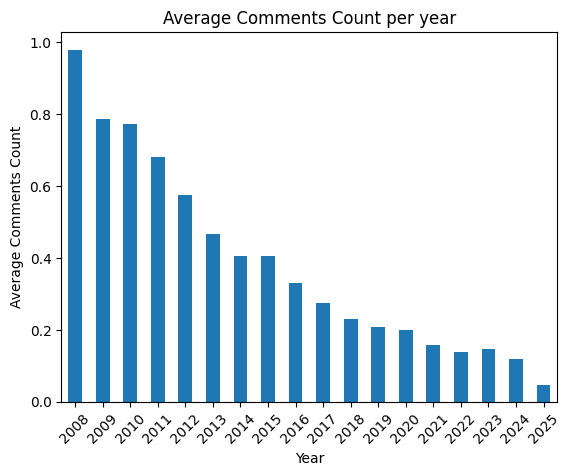

In [118]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag in days
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract year
df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]
# Group and average
avg_per_year = plot_df.groupby('year')['comments_count'].mean()

# Bar chart
plt.figure()
avg_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Comments Count")
plt.title("Average Comments Count per year")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

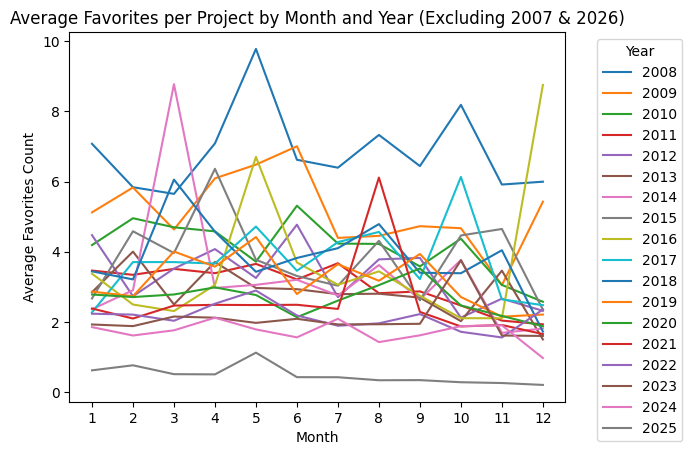

In [110]:
#are favorites count increasing over time
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]

# Group: average comments per (year, month)
grouped = df_filtered.groupby(['year', 'month'])['favorites_count'].mean().reset_index()

# Pivot so each year is a line
pivot = grouped.pivot(index='month', columns='year', values='favorites_count')

# Plot
plt.figure()
pivot.plot()

plt.xlabel("Month")
plt.ylabel("Average Favorites Count")
plt.title("Average Favorites per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

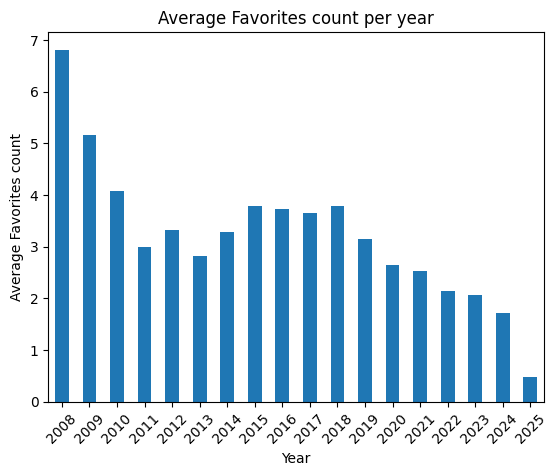

In [116]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag in days
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract year
df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]
# Group and average
avg_per_year = plot_df.groupby('year')['favorites_count'].mean()

# Bar chart
plt.figure()
avg_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Favorites count")
plt.title("Average Favorites count per year")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

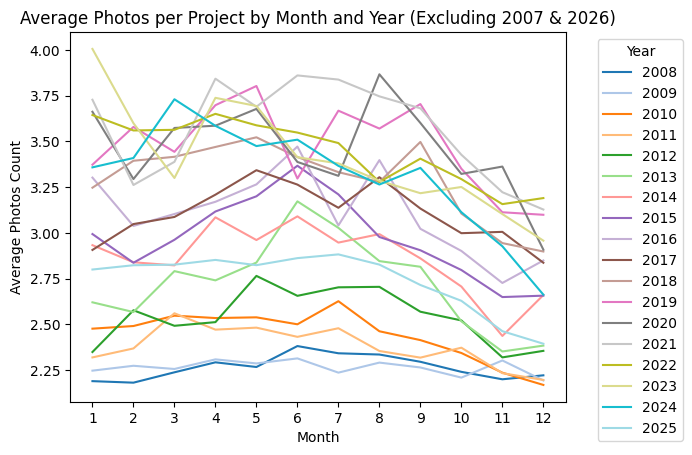

In [112]:
#how about photos_count
#are favorites count increasing over time
# Extract year and month
df['year'] = df['created_at_dt'].dt.year
df['month'] = df['created_at_dt'].dt.month

# leave out incomplete years
df_filtered = df[~df['year'].isin([2007, 2026])]

# Group: average comments per (year, month)
grouped = df_filtered.groupby(['year', 'month'])['photos_count'].mean().reset_index()

# Pivot so each year is a line
pivot = grouped.pivot(index='month', columns='year', values='photos_count')

# Plot
plt.figure()
pivot.plot(kind='line', cmap='tab20')

plt.xlabel("Month")
plt.ylabel("Average Photos Count")
plt.title("Average Photos per Project by Month and Year (Excluding 2007 & 2026)")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

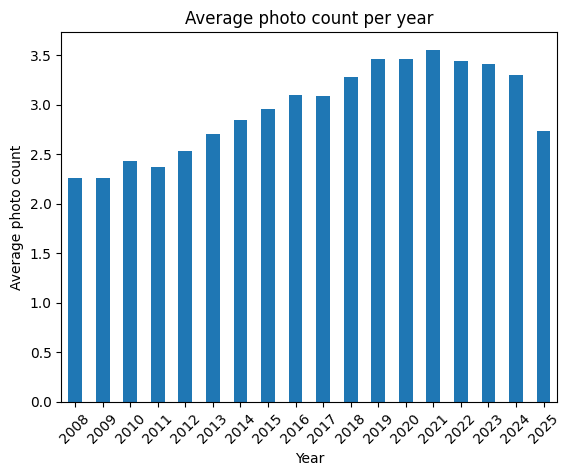

In [ ]:
# Convert to datetime
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
df['started_dt'] = pd.to_datetime(df['started'], errors='coerce', utc=True)

# Compute lag in days 
df['lag_days'] = (df['created_at_dt'] - df['started_dt']).dt.days
df['lag_days'] = df['lag_days'].where(df['started_day_set'])

# Extract year
df['year'] = df['created_at_dt'].dt.year
plot_df = df[~df['year'].isin([2007, 2026])]
# Group and average
avg_per_year = plot_df.groupby('year')['photos_count'].mean()

# Bar chart
plt.figure()
avg_per_year.plot(kind='bar')
plt.xlabel("Year")
plt.ylabel("Average Photo count")
plt.title("Average Photo count per year")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#are number of comments and number or favorites correlated

In [ ]:
#proportion of ratings per year over time